## Section 01 — ML Configuration and Reproducibility

In [42]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import sparse
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from xgboost import XGBClassifier

RANDOM_STATE = 42
TARGET = "Churned"
SCORING = "roc_auc"
THRESHOLD_SELECTION_METRIC = "F1"

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks" or not (PROJECT_ROOT / "data").exists():
    if (PROJECT_ROOT.parent / "data").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "customer_churn_feature_engineered.csv"
MODELS_DIR = PROJECT_ROOT / "models"
PREPROCESSOR_PATH = MODELS_DIR / "preprocessor.joblib"
METADATA_PATH = MODELS_DIR / "preprocessor_metadata.json"
SPLIT_PATH = MODELS_DIR / "data_split_indices.json"

print(f"Random state: {RANDOM_STATE}")
print(f"Target: {TARGET}")
print("Task: Binary Classification")
print(f"Scoring for model selection: {SCORING}")
print(f"Threshold selection metric: {THRESHOLD_SELECTION_METRIC}")

Random state: 42
Target: Churned
Task: Binary Classification
Scoring for model selection: roc_auc
Threshold selection metric: F1


## Section 02 — Load Preprocessed Data and Artifacts

Load the fitted preprocessing artifact and metadata from notebook 06. The preprocessor is reused with `transform` only; it is never fitted in this notebook.

In [43]:
with open(METADATA_PATH, "r", encoding="utf-8") as metadata_file:
    metadata = json.load(metadata_file)

with open(SPLIT_PATH, "r", encoding="utf-8") as split_file:
    split_indices = json.load(split_file)

preprocessor = joblib.load(PREPROCESSOR_PATH)
df = pd.read_csv(DATA_PATH)

assert metadata["target"] == TARGET
assert metadata["random_state"] == RANDOM_STATE
assert TARGET in df.columns

forbidden_features = metadata["forbidden_features"]
approved_features = metadata["approved_features"]

assert not set(forbidden_features).intersection(df.columns)
assert TARGET not in approved_features
assert set(approved_features).issubset(df.columns)

X = df[approved_features].copy()
y = df[TARGET].copy()

train_indices = split_indices["train_indices"]
validation_indices = split_indices["validation_indices"]
test_indices = split_indices["test_indices"]

# Reconstruct the exact train/validation/test split created in notebook 06.
X_train = X.loc[train_indices].copy()
y_train = y.loc[train_indices].copy()

X_valid = X.loc[validation_indices].copy()
y_valid = y.loc[validation_indices].copy()

X_test = X.loc[test_indices].copy()
y_test = y.loc[test_indices].copy()

# Reuse the fitted preprocessor from notebook 06.
# No fitting is performed in this notebook.
X_train_processed = preprocessor.transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)
X_test_processed = preprocessor.transform(X_test)

processed_feature_names = metadata["processed_feature_names"]

assert X_train_processed.shape[1] == X_valid_processed.shape[1]
assert X_valid_processed.shape[1] == X_test_processed.shape[1]

assert len(X_train_processed) == len(y_train)
assert len(X_valid_processed) == len(y_valid)
assert len(X_test_processed) == len(y_test)

assert set(train_indices).isdisjoint(validation_indices)
assert set(train_indices).isdisjoint(test_indices)
assert set(validation_indices).isdisjoint(test_indices)

assert set(train_indices) | set(validation_indices) | set(test_indices) == set(df.index)

assert X_train_processed.shape[1] == len(processed_feature_names)

print(f"Train: {X_train_processed.shape}")
print(f"Validation: {X_valid_processed.shape}")
print(f"Test: {X_test_processed.shape}")

Train: (35000, 54)
Validation: (7500, 54)
Test: (7500, 54)


## Section 03 — ML Dataset Audit

In [44]:
# Section 03 — ML Dataset Audit
def dataset_summary(name, features, target):
    return {
        "Dataset": name,
        "Rows": len(target),
        "Features": features.shape[1],
        "Churn 0": int((target == 0).sum()),
        "Churn 1": int((target == 1).sum()),
        "Churn Rate": target.mean(),
    }

def assert_no_nan(matrix):
    if sparse.issparse(matrix):
        assert not np.isnan(matrix.data).any(), "NaN remains in sparse processed data."
    else:
        assert not np.isnan(matrix).any(), "NaN remains in processed data."

summary_table = pd.DataFrame([
    dataset_summary("Train", X_train_processed, y_train),
    dataset_summary("Validation", X_valid_processed, y_valid),
    dataset_summary("Test", X_test_processed, y_test),
])

assert sorted(y_train.unique().tolist()) == [0, 1]
assert set(y_valid.unique()).issubset({0, 1})
assert set(y_test.unique()).issubset({0, 1})
assert_no_nan(X_train_processed)
assert_no_nan(X_valid_processed)
assert_no_nan(X_test_processed)

print(summary_table.to_string(index=False, formatters={"Churn Rate": "{:.4f}".format}))

   Dataset  Rows  Features  Churn 0  Churn 1 Churn Rate
     Train 35000        54    24885    10115     0.2890
Validation  7500        54     5332     2168     0.2891
      Test  7500        54     5333     2167     0.2889


## Section 04 — Baseline Model

In [45]:
def evaluate_predictions(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba),
    }

def evaluate_model(model, features, target, threshold=0.5):
    probabilities = model.predict_proba(features)[:, 1]
    predictions = (probabilities >= threshold).astype(int)
    return evaluate_predictions(target, predictions, probabilities), predictions, probabilities

def print_diagnostics(name, metrics, target, predictions):
    print(f"\n{name} Performance")
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(target, predictions))
    print("Classification Report:")
    print(classification_report(target, predictions, zero_division=0))

baseline_model = DummyClassifier(strategy="prior", random_state=RANDOM_STATE)
baseline_model.fit(X_train_processed, y_train)
baseline_metrics, baseline_valid_pred, baseline_valid_proba = evaluate_model(
    baseline_model, X_valid_processed, y_valid
)
print_diagnostics("Baseline", baseline_metrics, y_valid, baseline_valid_pred)


Baseline Performance
Accuracy: 0.7109
Precision: 0.0000
Recall: 0.0000
F1: 0.0000
ROC-AUC: 0.5000
PR-AUC: 0.2891
Confusion Matrix:
[[5332    0]
 [2168    0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.71      1.00      0.83      5332
           1       0.00      0.00      0.00      2168

    accuracy                           0.71      7500
   macro avg       0.36      0.50      0.42      7500
weighted avg       0.51      0.71      0.59      7500



## Section 05 — Logistic Regression
Train the initial Logistic Regression model on the processed training set and evaluate it on the validation set.

In [46]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
)

logistic_model.fit(X_train_processed, y_train)

logistic_metrics, logistic_valid_pred, logistic_valid_proba = evaluate_model(
    logistic_model,
    X_valid_processed,
    y_valid,
)

print_diagnostics(
    "Logistic Regression",
    logistic_metrics,
    y_valid,
    logistic_valid_pred,
)

initial_results = [
    {"Model": "Dummy", **baseline_metrics},
    {"Model": "Logistic Regression", **logistic_metrics},
]

initial_predictions = {
    "Dummy": baseline_valid_pred,
    "Logistic Regression": logistic_valid_pred,
}

initial_probabilities = {
    "Dummy": baseline_valid_proba,
    "Logistic Regression": logistic_valid_proba,
}


Logistic Regression Performance
Accuracy: 0.7961
Precision: 0.7226
Recall: 0.4783
F1: 0.5756
ROC-AUC: 0.8166
PR-AUC: 0.6871
Confusion Matrix:
[[4934  398]
 [1131 1037]]
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.93      0.87      5332
           1       0.72      0.48      0.58      2168

    accuracy                           0.80      7500
   macro avg       0.77      0.70      0.72      7500
weighted avg       0.79      0.80      0.78      7500



## Section 06 — Random Forest

In [47]:
random_forest_model = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

random_forest_model.fit(X_train_processed, y_train)

random_forest_metrics, random_forest_valid_pred, random_forest_valid_proba = evaluate_model(
    random_forest_model,
    X_valid_processed,
    y_valid,
)

print_diagnostics(
    "Random Forest",
    random_forest_metrics,
    y_valid,
    random_forest_valid_pred,
)

initial_results.append(
    {
        "Model": "Random Forest",
        **random_forest_metrics,
    }
)

initial_predictions["Random Forest"] = random_forest_valid_pred
initial_probabilities["Random Forest"] = random_forest_valid_proba


Random Forest Performance
Accuracy: 0.9123
Precision: 0.9064
Recall: 0.7768
F1: 0.8366
ROC-AUC: 0.9244
PR-AUC: 0.8950
Confusion Matrix:
[[5158  174]
 [ 484 1684]]
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      5332
           1       0.91      0.78      0.84      2168

    accuracy                           0.91      7500
   macro avg       0.91      0.87      0.89      7500
weighted avg       0.91      0.91      0.91      7500



## Section 07 — XGBoost

In [48]:
xgboost_model = XGBClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric="logloss",
    tree_method="hist",
)

xgboost_model.fit(X_train_processed, y_train)

xgboost_metrics, xgboost_valid_pred, xgboost_valid_proba = evaluate_model(
    xgboost_model,
    X_valid_processed,
    y_valid,
)

print_diagnostics(
    "XGBoost",
    xgboost_metrics,
    y_valid,
    xgboost_valid_pred,
)

initial_results.append(
    {
        "Model": "XGBoost",
        **xgboost_metrics,
    }
)

initial_predictions["XGBoost"] = xgboost_valid_pred
initial_probabilities["XGBoost"] = xgboost_valid_proba


XGBoost Performance
Accuracy: 0.9145
Precision: 0.9068
Recall: 0.7851
F1: 0.8415
ROC-AUC: 0.9266
PR-AUC: 0.9070
Confusion Matrix:
[[5157  175]
 [ 466 1702]]
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      5332
           1       0.91      0.79      0.84      2168

    accuracy                           0.91      7500
   macro avg       0.91      0.88      0.89      7500
weighted avg       0.91      0.91      0.91      7500



In [49]:
model_results = pd.DataFrame(initial_results)[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC",
    ]
]

print(
    model_results.to_string(
        index=False,
        float_format="{:.4f}".format,
    )
)

              Model  Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC
              Dummy    0.7109     0.0000  0.0000 0.0000   0.5000  0.2891
Logistic Regression    0.7961     0.7226  0.4783 0.5756   0.8166  0.6871
      Random Forest    0.9123     0.9064  0.7768 0.8366   0.9244  0.8950
            XGBoost    0.9145     0.9068  0.7851 0.8415   0.9266  0.9070


## Section 08 — Initial Model Comparison

              Model  Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC
              Dummy    0.7109     0.0000  0.0000 0.0000   0.5000  0.2891
Logistic Regression    0.7961     0.7226  0.4783 0.5756   0.8166  0.6871
      Random Forest    0.9123     0.9064  0.7768 0.8366   0.9244  0.8950
            XGBoost    0.9145     0.9068  0.7851 0.8415   0.9266  0.9070


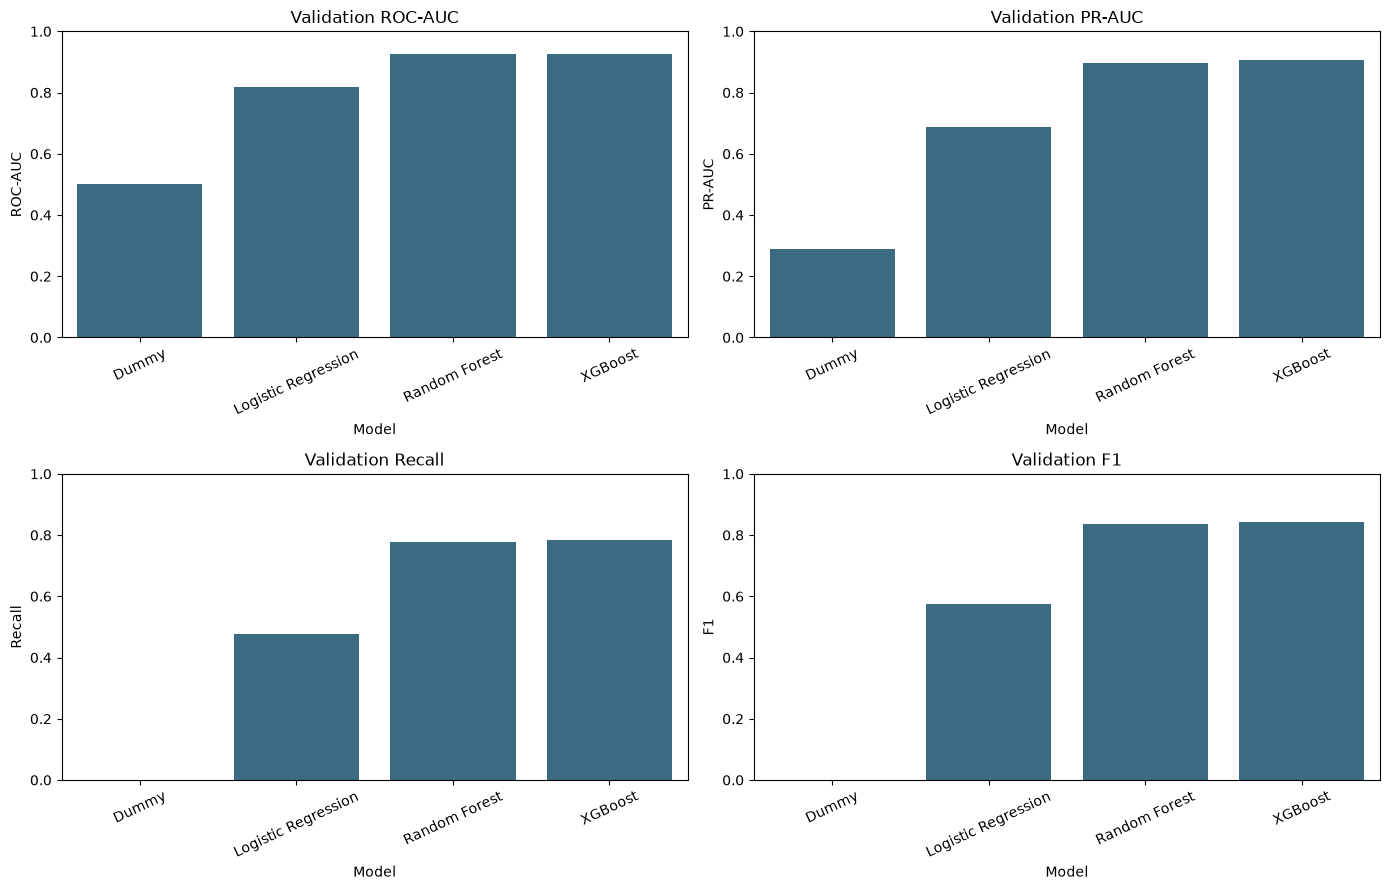

In [50]:
# Section 08 — Initial Model Comparison
print(model_results.to_string(index=False, float_format="{:.4f}".format))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for metric_name, axis in zip(
    ["ROC-AUC", "PR-AUC", "Recall", "F1"], axes.ravel()
):
    sns.barplot(data=model_results, x="Model", y=metric_name, ax=axis, color="#2f6f8f")
    axis.set_title(f"Validation {metric_name}")
    axis.set_ylim(0, 1)
    axis.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

## Section 09 — Hyperparameter Tuning

Tune only on the training data with `StratifiedKFold` and fixed ROC-AUC scoring. Validation and test remain untouched by the searches.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
searches = {
    "Tuned Logistic": (
        LogisticRegression(max_iter=1500, random_state=RANDOM_STATE),
        {"C": [0.01, 0.1, 1.0, 10.0], "solver": ["lbfgs", "liblinear"], "class_weight": [None, "balanced"]},
        8,
    ),
    "Tuned RF": (
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        {
            "n_estimators": [200, 400], "max_depth": [None, 10, 20],
            "min_samples_split": [2, 5, 10], "min_samples_leaf": [1, 2, 4],
            "max_features": ["sqrt", "log2"],
        },
        12,
    ),
    "Tuned XGBoost": (
        XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, eval_metric="logloss", tree_method="hist"),
        {
            "n_estimators": [200, 400], "max_depth": [3, 5, 7], "learning_rate": [0.03, 0.1],
            "subsample": [0.8, 1.0], "colsample_bytree": [0.8, 1.0], "min_child_weight": [1, 3, 5],
        },
        12,
    ),
}

tuned_searches = {}
tuned_models = {}
for name, (estimator, parameter_distributions, n_iter) in searches.items():
    search = RandomizedSearchCV(
        estimator, parameter_distributions, n_iter=n_iter, scoring=SCORING,
        cv=cv, random_state=RANDOM_STATE, n_jobs=-1, refit=True,
    )
    search.fit(X_train_processed, y_train)
    tuned_searches[name] = search
    tuned_models[name] = search.best_estimator_
    print(f"{name}: CV ROC-AUC={search.best_score_:.4f}")
    print(f"Best parameters: {search.best_params_}\n")

Tuned Logistic: CV ROC-AUC=0.8171
Best parameters: {'solver': 'liblinear', 'class_weight': None, 'C': 0.1}



## Section 10 — Validation-based Model Selection

### Model Selection Criterion

The primary selection metric is ROC-AUC because it measures discrimination independently of a classification threshold. PR-AUC, Recall, and F1 are retained as supporting metrics. The final candidate is selected using validation ROC-AUC after training-only cross-validation.

In [ ]:
selection_rows = []
for name, model in tuned_models.items():
    metrics, predictions, probabilities = evaluate_model(model, X_valid_processed, y_valid)
    selection_rows.append({
        "Model": name,
        "CV Score": tuned_searches[name].best_score_,
        "Validation Accuracy": metrics["Accuracy"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "F1": metrics["F1"],
        "ROC-AUC": metrics["ROC-AUC"],
        "PR-AUC": metrics["PR-AUC"],
    })
validation_results = pd.DataFrame(selection_rows).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
print(validation_results.to_string(index=False, float_format="{:.4f}".format))

selected_model_name = validation_results.loc[0, "Model"]
final_model = tuned_models[selected_model_name]
final_hyperparameters = tuned_searches[selected_model_name].best_params_
print(f"Selected model by validation ROC-AUC: {selected_model_name}")

         Model  CV Score  Validation Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC
 Tuned XGBoost    0.9257               0.9203     0.9162  0.7970 0.8525   0.9278  0.9106
      Tuned RF    0.9213               0.9123     0.9077  0.7754 0.8363   0.9260  0.8997
Tuned Logistic    0.8171               0.7961     0.7233  0.4774 0.5752   0.8166  0.6869
Selected model by validation ROC-AUC: Tuned XGBoost


## Section 11 — Threshold Analysis

Threshold selection is performed on the validation set only. The selected threshold maximizes validation F1, which balances precision and recall. This is a project baseline criterion, not an absolute business optimum; a recall or cost-based criterion may be appropriate if business priorities change.

 Threshold  Precision  Recall     F1
    0.1000     0.6347  0.8967 0.7433
    0.1500     0.7300  0.8856 0.8003
    0.2000     0.7787  0.8764 0.8247
    0.2500     0.8171  0.8676 0.8416
    0.3000     0.8512  0.8524 0.8518
    0.3500     0.8713  0.8367 0.8536
    0.4000     0.8909  0.8247 0.8565
    0.4500     0.9040  0.8123 0.8557
    0.5000     0.9162  0.7970 0.8525
    0.5500     0.9304  0.7837 0.8508
    0.6000     0.9391  0.7615 0.8411
    0.6500     0.9474  0.7399 0.8309
    0.7000     0.9554  0.7205 0.8215
    0.7500     0.9610  0.6942 0.8061
    0.8000     0.9696  0.6610 0.7861
    0.8500     0.9769  0.6232 0.7609
    0.9000     0.9829  0.5826 0.7315
Final threshold selected on validation F1: 0.40


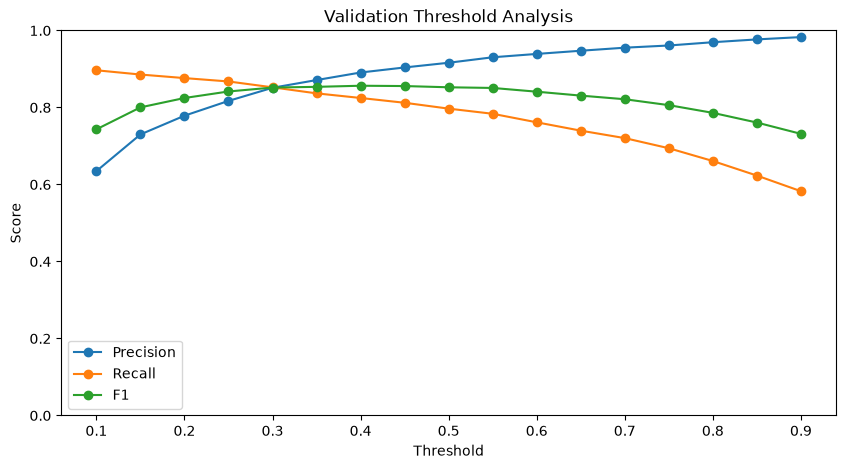

In [ ]:
final_valid_proba = final_model.predict_proba(X_valid_processed)[:, 1]
thresholds = np.round(np.arange(0.10, 0.91, 0.05), 2)
threshold_rows = []
for threshold in thresholds:
    threshold_predictions = (final_valid_proba >= threshold).astype(int)
    threshold_rows.append({
        "Threshold": threshold,
        "Precision": precision_score(y_valid, threshold_predictions, zero_division=0),
        "Recall": recall_score(y_valid, threshold_predictions, zero_division=0),
        "F1": f1_score(y_valid, threshold_predictions, zero_division=0),
    })
threshold_results = pd.DataFrame(threshold_rows)
FINAL_THRESHOLD = float(threshold_results.loc[threshold_results["F1"].idxmax(), "Threshold"])
print(threshold_results.to_string(index=False, float_format="{:.4f}".format))
print(f"Final threshold selected on validation F1: {FINAL_THRESHOLD:.2f}")

threshold_results.set_index("Threshold")[["Precision", "Recall", "F1"]].plot(marker="o", figsize=(10, 5))
plt.ylim(0, 1)
plt.title("Validation Threshold Analysis")
plt.ylabel("Score")
plt.show()

## Section 12 — Final Test Evaluation

The test set is used only after model selection and threshold selection are fixed.

   Metric   Test
 Accuracy 0.9224
Precision 0.8957
   Recall 0.8279
       F1 0.8604
  ROC-AUC 0.9265
   PR-AUC 0.9054


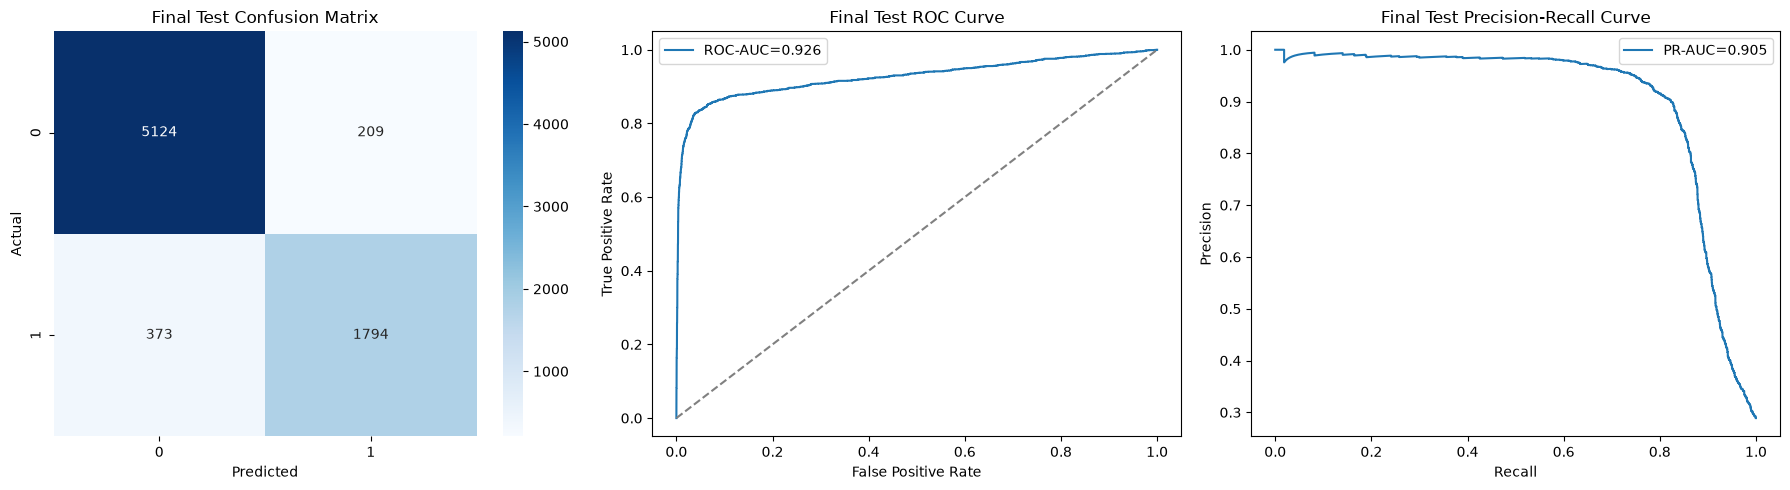

In [ ]:
final_test_proba = final_model.predict_proba(X_test_processed)[:, 1]
final_test_pred = (final_test_proba >= FINAL_THRESHOLD).astype(int)
test_metrics = evaluate_predictions(y_test, final_test_pred, final_test_proba)
final_test_results = pd.DataFrame({"Metric": list(test_metrics), "Test": list(test_metrics.values())})
print(final_test_results.to_string(index=False, float_format="{:.4f}".format))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.heatmap(confusion_matrix(y_test, final_test_pred), annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Final Test Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

fpr, tpr, _ = roc_curve(y_test, final_test_proba)
axes[1].plot(fpr, tpr, label=f"ROC-AUC={test_metrics['ROC-AUC']:.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_title("Final Test ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

precision, recall, _ = precision_recall_curve(y_test, final_test_proba)
axes[2].plot(recall, precision, label=f"PR-AUC={test_metrics['PR-AUC']:.3f}")
axes[2].set_title("Final Test Precision-Recall Curve")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].legend()
plt.tight_layout()
plt.show()

## Section 13 — Feature Importance

For Logistic Regression, coefficient sign indicates the direction of association with predicted churn log-odds, while absolute magnitude is used for relative ranking. Feature importance and coefficients are not causal effects.

                                Feature  Importance  Absolute Importance
cat__Service_Call_Group_No_or_Few_Calls    0.320875             0.320875
  cat__Service_Call_Group_Very_Frequent    0.133135             0.133135
            num__Low_Engagement_Recency    0.064252             0.064252
                    num__Lifetime_Value    0.055035             0.055035
       cat__Cart_Abandonment_Group_High    0.043302             0.043302
       cat__Service_Call_Group_Frequent    0.040123             0.040123
            num__Customer_Service_Calls    0.037763             0.037763
               num__Discount_Usage_Rate    0.035232             0.035232
                  num__Engagement_Score    0.034686             0.034686
     cat__Purchase_Recency_Group_Recent    0.030031             0.030031
             num__Cart_Abandonment_Rate    0.026016             0.026016
                               num__Age    0.023292             0.023292
          num__Cart_Recency_Interaction    0.014018

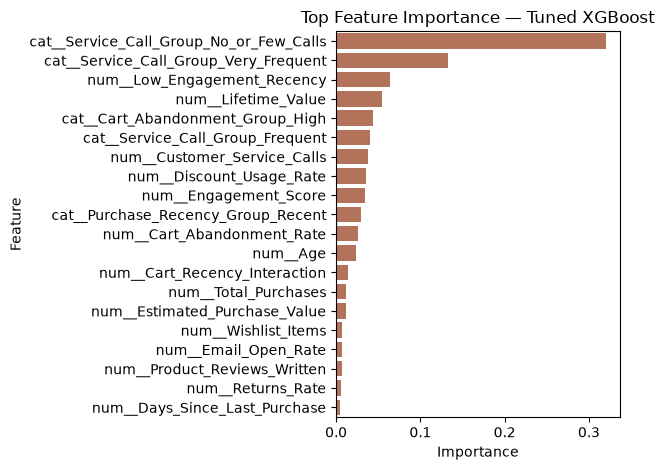

In [ ]:
if hasattr(final_model, "coef_"):
    importance_values = final_model.coef_[0]
else:
    importance_values = final_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": processed_feature_names,
    "Importance": importance_values,
})
feature_importance["Absolute Importance"] = feature_importance["Importance"].abs()
feature_importance = feature_importance.sort_values("Absolute Importance", ascending=False).reset_index(drop=True)
print(feature_importance.head(20).to_string(index=False))

sns.barplot(data=feature_importance.head(20), y="Feature", x="Importance", color="#c26b4b")
plt.title(f"Top Feature Importance — {selected_model_name}")
plt.tight_layout()
plt.show()

## Section 14 — Save Final ML Artifacts and Validate Pipeline

In [ ]:
final_model_path = MODELS_DIR / "final_model.joblib"
final_metadata_path = MODELS_DIR / "final_model_metadata.json"
joblib.dump(final_model, final_model_path)

validation_metrics = validation_results.loc[
    validation_results["Model"] == selected_model_name
].iloc[0].to_dict()
final_model_metadata = {
    "target": TARGET,
    "model_name": selected_model_name,
    "random_state": RANDOM_STATE,
    "scoring": SCORING,
    "threshold": FINAL_THRESHOLD,
    "threshold_selection_metric": THRESHOLD_SELECTION_METRIC,
    "feature_source": "06_preprocessing",
    "preprocessor_path": str(PREPROCESSOR_PATH),
    "original_feature_count": len(approved_features),
    "processed_feature_count": len(processed_feature_names),
    "processed_feature_names": processed_feature_names,
    "validation_metrics": validation_metrics,
    "test_metrics": test_metrics,
    "hyperparameters": final_hyperparameters,
}
with open(final_metadata_path, "w", encoding="utf-8") as metadata_file:
    json.dump(final_model_metadata, metadata_file, indent=2, ensure_ascii=False, default=float)

assert TARGET == "Churned"
assert final_model is not None
assert 0 < FINAL_THRESHOLD < 1
assert len(processed_feature_names) == X_train_processed.shape[1]
assert_no_nan(X_train_processed)
assert_no_nan(X_valid_processed)
assert_no_nan(X_test_processed)
assert final_model_path.exists()
assert final_metadata_path.exists()

print("ML Pipeline Validation: PASSED")
print(f"Saved model: {final_model_path}")
print(f"Saved metadata: {final_metadata_path}")

ML Pipeline Validation: PASSED
Saved model: D:\Desktop\Projects\customer-churn-analytics\models\final_model.joblib
Saved metadata: D:\Desktop\Projects\customer-churn-analytics\models\final_model_metadata.json


In [ ]:
print("=" * 50)
print("MACHINE LEARNING SUMMARY")
print("=" * 50)
print("Task: Binary Classification")
print(f"Target: {TARGET}")
print(f"Training samples: {len(y_train)}")
print(f"Validation samples: {len(y_valid)}")
print(f"Test samples: {len(y_test)}")
print(f"Original features: {len(approved_features)}")
print(f"Processed features: {len(processed_feature_names)}")
print("Models evaluated: Dummy Classifier, Logistic Regression, Random Forest, XGBoost")
print(f"Final Model: {selected_model_name}")
print(f"Decision Threshold: {FINAL_THRESHOLD:.2f}")
print(f"Validation ROC-AUC: {validation_metrics['ROC-AUC']:.4f}")
print(f"Test ROC-AUC: {test_metrics['ROC-AUC']:.4f}")
print(f"Test PR-AUC: {test_metrics['PR-AUC']:.4f}")
print(f"Test Recall: {test_metrics['Recall']:.4f}")
print(f"Test F1: {test_metrics['F1']:.4f}")
print(f"Final model saved to: {final_model_path}")
print("=" * 50)

MACHINE LEARNING SUMMARY
Task: Binary Classification
Target: Churned
Training samples: 35000
Validation samples: 7500
Test samples: 7500
Original features: 32
Processed features: 54
Models evaluated: Dummy Classifier, Logistic Regression, Random Forest, XGBoost
Final Model: Tuned XGBoost
Decision Threshold: 0.40
Validation ROC-AUC: 0.9278
Test ROC-AUC: 0.9265
Test PR-AUC: 0.9054
Test Recall: 0.8279
Test F1: 0.8604
Final model saved to: D:\Desktop\Projects\customer-churn-analytics\models\final_model.joblib
